In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
plt.style.use('default')
sns.set_palette("husl")


## Dataset exploration

In [103]:
try:
    df = pd.read_csv('cause_of_deaths.csv')
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("dataset not found")
    
    df = None

   Shape: 6,120 rows × 34 columns


In [104]:
df.head()

,Country/Territory,Code,Year,Meningitis,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Nutritional Deficiencies,Malaria,Drowning,Interpersonal Violence,...,Diabetes Mellitus,Chronic Kidney Disease,Poisonings,Protein-Energy Malnutrition,Road Injuries,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,Digestive Diseases,"Fire, Heat, and Hot Substances",Acute Hepatitis
0,Afghanistan,AFG,1990,2159,1116,371,2087,93,1370,1538,...,2108,3709,338,2054,4154,5945,2673,5005,323,2985
1,Afghanistan,AFG,1991,2218,1136,374,2153,189,1391,2001,...,2120,3724,351,2119,4472,6050,2728,5120,332,3092
2,Afghanistan,AFG,1992,2475,1162,378,2441,239,1514,2299,...,2153,3776,386,2404,5106,6223,2830,5335,360,3325
3,Afghanistan,AFG,1993,2812,1187,384,2837,108,1687,2589,...,2195,3862,425,2797,5681,6445,2943,5568,396,3601
4,Afghanistan,AFG,1994,3027,1211,391,3081,211,1809,2849,...,2231,3932,451,3038,6001,6664,3027,5739,420,3816


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6120 entries, 0 to 6119
Data columns (total 34 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Country/Territory                           6120 non-null   object
 1   Code                                        6120 non-null   object
 2   Year                                        6120 non-null   int64 
 3   Meningitis                                  6120 non-null   int64 
 4   Alzheimer's Disease and Other Dementias     6120 non-null   int64 
 5   Parkinson's Disease                         6120 non-null   int64 
 6   Nutritional Deficiencies                    6120 non-null   int64 
 7   Malaria                                     6120 non-null   int64 
 8   Drowning                                    6120 non-null   int64 
 9   Interpersonal Violence                      6120 non-null   int64 
 10  Maternal Disorders      

In [106]:

if df is not None:
    # Basic dataset information
    print(f"\nTEMPORAL AND GEOGRAPHIC COVERAGE:")
    year_range = df['Year'].max() - df['Year'].min() + 1
    print(f"Years: {df['Year'].min()} - {df['Year'].max()} ({year_range} years)")
    print(f"Countries/Territories: {df['Country/Territory'].nunique()}")
    print(f"Average data points per year: {df.shape[0] // year_range:.0f}")
    print(f"Average years per country: {len(df) // df['Country/Territory'].nunique():.0f}")
    
    # Identify columns
    metadata_cols = ['Country/Territory', 'Code', 'Year']
    cause_columns = [col for col in df.columns if col not in metadata_cols]
    
    print(f"\nCOLUMN STRUCTURE:")
    print(f"Metadata columns: {len(metadata_cols)} - {metadata_cols}")
    print(f"Cause-of-death columns: {len(cause_columns)} (mortality features)")
    
    # Data quality check
    missing_total = df.isnull().sum().sum()
    print(f"Missing values: {missing_total:,}")
    if missing_total == 0:
        print("no missing values")
    
    # Check for negative values
    cause_data = df[cause_columns]
    negative_values = (cause_data < 0).sum().sum()
    print(f"Negative values: {negative_values}")
    if negative_values == 0:
        print("no negative death counts")
    
    # Global mortality overview
    print(f"\nGLOBAL MORTALITY:")
    global_cause_totals = df[cause_columns].sum().sort_values(ascending=False)
    total_global_deaths = global_cause_totals.sum()
    print(f"Total deaths recorded (1990-2019): {total_global_deaths:,}")
    print(f"Average deaths per country per year: {total_global_deaths // len(df):,}")


TEMPORAL AND GEOGRAPHIC COVERAGE:
Years: 1990 - 2019 (30 years)
Countries/Territories: 204
Average data points per year: 204
Average years per country: 30

COLUMN STRUCTURE:
Metadata columns: 3 - ['Country/Territory', 'Code', 'Year']
Cause-of-death columns: 31 (mortality features)
Missing values: 0
no missing values
Negative values: 0
no negative death counts

GLOBAL MORTALITY:
Total deaths recorded (1990-2019): 1,468,134,716
Average deaths per country per year: 239,891


In [107]:
print(f"\nTOP 10 CAUSES OF DEATH GLOBALLY:")
print("   Rank | Cause                                    | Deaths        | Percentage")
for i, (cause, deaths) in enumerate(global_cause_totals.head(10).items(), 1):
    percentage = (deaths / total_global_deaths) * 100
    print(f"   {i:2d}   | {cause:<40} | {deaths:>12,} | {percentage:>7.1f}%")

# Top countries by total mortality
print(f"\nTOP 10 COUNTRIES BY MORTALITY (1990-2019):")
country_deaths = df.groupby('Country/Territory')[cause_columns].sum()
total_deaths_per_country = country_deaths.sum(axis=1)
top_10_countries = total_deaths_per_country.nlargest(10)

print("   Rank | Country              | Total Deaths")
for i, (country, deaths) in enumerate(top_10_countries.items(), 1):
    print(f"   {i:2d}   | {country:<20} | {deaths:>12,}")


TOP 10 CAUSES OF DEATH GLOBALLY:
   Rank | Cause                                    | Deaths        | Percentage
    1   | Cardiovascular Diseases                  |  447,741,982 |    30.5%
    2   | Neoplasms                                |  229,758,538 |    15.6%
    3   | Chronic Respiratory Diseases             |  104,605,334 |     7.1%
    4   | Lower Respiratory Infections             |   83,770,038 |     5.7%
    5   | Neonatal Disorders                       |   76,860,729 |     5.2%
    6   | Diarrheal Diseases                       |   66,235,508 |     4.5%
    7   | Digestive Diseases                       |   65,638,635 |     4.5%
    8   | Tuberculosis                             |   45,850,603 |     3.1%
    9   | Cirrhosis and Other Chronic Liver Diseases |   37,479,321 |     2.6%
   10   | HIV/AIDS                                 |   36,364,419 |     2.5%

TOP 10 COUNTRIES BY MORTALITY (1990-2019):
   Rank | Country              | Total Deaths
    1   | China         

## Dataset split according to years

In [108]:
if df is not None:
    # Training period: 1990-2009 (features)
    training_period = df[df['Year'] <= 2009].copy()
    print(f"Training period (1990-2009): {len(training_period):,} country-year observations")
    
    # Prediction period: 2010-2019 (target labels) 
    prediction_period = df[df['Year'] >= 2010].copy()
    print(f"Prediction period (2010-2019): {len(prediction_period):,} country-year observations")
    
    # Training features: Average mortality patterns 1990-2009 per country
    training_features = training_period.groupby('Country/Territory')[cause_columns].mean().reset_index()
    print(f"Training features: {len(training_features)} countries with 1990-2009 mortality patterns")
    
    # Prediction targets: Dominant disease patterns 2010-2019 per country
    prediction_targets = prediction_period.groupby('Country/Territory')[cause_columns].mean().reset_index()
    print(f"Prediction targets: {len(prediction_targets)} countries with 2010-2019 disease profiles")
    
    # Find countries present in both periods
    common_countries = set(training_features['Country/Territory']) & set(prediction_targets['Country/Territory'])
    # print(f"Countries with data in both periods: {len(common_countries)}")
    
    # For each country, determine top 3 causes in prediction period (2010-2019)
    future_profiles = []
    for country in common_countries:
        # Get country's mortality data for 2010-2019 
        country_data = prediction_targets[prediction_targets['Country/Territory'] == country]
        if len(country_data) == 0:
            continue
        # Get average deaths per cause for this country in 2010-2019
        cause_values = country_data[cause_columns].iloc[0]
        # Sort by death count to get top 3 causes
        top3_causes = cause_values.nlargest(3)
        top3_names = top3_causes.index.tolist()
        
        future_profiles.append({'Country': country,'Top1_Future': top3_names[0],'Top2_Future': top3_names[1],'Top3_Future': top3_names[2],'Total_Deaths_Future': cause_values.sum()})
    
    # Convert to DataFrame
    future_profile_df = pd.DataFrame(future_profiles)
    
    # print(f"Created future disease profiles for {len(future_profile_df)} countries")
    
    # Show most common future #1 causes
    print(f"\nMOST COMMON FUTURE CAUSES (2010-2019):")
    future_top1_counts = future_profile_df['Top1_Future'].value_counts().head(8)
    for i, (cause, count) in enumerate(future_top1_counts.items(), 1):
        percentage = (count / len(future_profile_df)) * 100
        print(f"   {i:2d}. {cause:<35} | {count:>3} countries ({percentage:>5.1f}%)")
    
    # Define disease profile classification for temporal prediction
    def classify_future_disease_profile(row):
        top3_future = [row['Top1_Future'], row['Top2_Future'], row['Top3_Future']]
        
        # Define disease categories for future classification
        chronic_diseases = {'Cardiovascular Diseases', 'Neoplasms', 'Diabetes Mellitus', 'Chronic Kidney Disease', 'Chronic Respiratory Diseases',"Alzheimer's Disease and Other Dementias", "Parkinson's Disease"}
        infectious_diseases = {'Tuberculosis', 'HIV/AIDS', 'Malaria', 'Diarrheal Diseases','Lower Respiratory Infections', 'Meningitis', 'Acute Hepatitis'}
        maternal_child_diseases = {'Maternal Disorders', 'Neonatal Disorders', 'Nutritional Deficiencies','Protein-Energy Malnutrition'}
        
        # Count categories in future top 3
        chronic_count = sum(1 for cause in top3_future if cause in chronic_diseases)
        infectious_count = sum(1 for cause in top3_future if cause in infectious_diseases)
        maternal_child_count = sum(1 for cause in top3_future if cause in maternal_child_diseases)
        
        # Only if chronic diseases completely dominate (all 3 are chronic)
        if chronic_count == 3:
            return 'Chronic_Dominant_Future'
        
        # 2. Infectious-Dominant Future: Persistent infectious burden
        elif infectious_count >= 2 or maternal_child_count >= 2 or (infectious_count >= 1 and maternal_child_count >= 1):
            return 'Infectious_Dominant_Future'
            
        # 3. Transitional Future: Mixed epidemiological stage 
        else:
            return 'Transitional_Future'
    
    # Apply future classification
    future_profile_df['Future_Disease_Profile'] = future_profile_df.apply(classify_future_disease_profile, axis=1)
    
    # Analyze future profile distribution  
    print(f"\nFUTURE DISEASE PROFILE DISTRIBUTION (2010-2019):")
    future_profile_counts = future_profile_df['Future_Disease_Profile'].value_counts()
    print("   Future Profile                | Count | Percentage | Description")
    print("   " + "-" * 80)
    
    future_profile_descriptions = {
        'Chronic_Dominant_Future': 'Fully transitioned','Infectious_Dominant_Future': 'Early stage - strong infectious/maternal disease burden', 'Transitional_Future': 'Mid-transition - mixed chronic + infectious patterns'}
    
    for profile in future_profile_counts.index:
        count = future_profile_counts[profile]
        percentage = (count / len(future_profile_df)) * 100
        description = future_profile_descriptions.get(profile, 'Other future patterns')
        print(f"   {profile:<28} | {count:>5} | {percentage:>8.1f}% | {description}")
    
    # Check balance for future profiles
    max_class = future_profile_counts.max()
    min_class = future_profile_counts.min()
    imbalance_ratio = max_class / min_class

Training period (1990-2009): 4,080 country-year observations
Prediction period (2010-2019): 2,040 country-year observations
Training features: 204 countries with 1990-2009 mortality patterns
Prediction targets: 204 countries with 2010-2019 disease profiles

MOST COMMON FUTURE CAUSES (2010-2019):
    1. Cardiovascular Diseases             | 155 countries ( 76.0%)
    2. Neoplasms                           |  20 countries (  9.8%)
    3. HIV/AIDS                            |  15 countries (  7.4%)
    4. Malaria                             |   7 countries (  3.4%)
    5. Neonatal Disorders                  |   3 countries (  1.5%)
    6. Lower Respiratory Infections        |   2 countries (  1.0%)
    7. Tuberculosis                        |   1 countries (  0.5%)
    8. Diarrheal Diseases                  |   1 countries (  0.5%)

FUTURE DISEASE PROFILE DISTRIBUTION (2010-2019):
   Future Profile                | Count | Percentage | Description
   --------------------------------------

In [109]:
print(f"\nTEMPORAL PREDICTION:")
for profile_type in future_profile_counts.index:
    examples = future_profile_df[future_profile_df['Future_Disease_Profile'] == profile_type].head(3)
    print(f"\n   {profile_type}:")
    for _, example in examples.iterrows():
        print(f"   • {example['Country']}: {example['Top1_Future']} → {example['Top2_Future']} → {example['Top3_Future']}")



TEMPORAL PREDICTION:

   Chronic_Dominant_Future:
   • Bhutan: Cardiovascular Diseases → Chronic Respiratory Diseases → Neoplasms
   • Saint Kitts and Nevis: Cardiovascular Diseases → Neoplasms → Diabetes Mellitus
   • Panama: Cardiovascular Diseases → Neoplasms → Diabetes Mellitus

   Transitional_Future:
   • Turkmenistan: Cardiovascular Diseases → Neoplasms → Digestive Diseases
   • South Korea: Neoplasms → Cardiovascular Diseases → Digestive Diseases
   • Cambodia: Cardiovascular Diseases → Neoplasms → Lower Respiratory Infections

   Infectious_Dominant_Future:
   • Mauritania: Cardiovascular Diseases → Neonatal Disorders → Diarrheal Diseases
   • Uganda: HIV/AIDS → Neonatal Disorders → Malaria
   • Ethiopia: Neonatal Disorders → Cardiovascular Diseases → Diarrheal Diseases


In [110]:
if df is not None:
    temporal_dataset = []
    for country in common_countries:
        # Get historical features (1990-2009)
        historical_data = training_features[training_features['Country/Territory'] == country]
        if len(historical_data) == 0:
            continue
        historical_values = historical_data.iloc[0]
        
        # Get future target (2010-2019)
        future_data = future_profile_df[future_profile_df['Country'] == country]
        if len(future_data) == 0:
            continue
        future_target = future_data.iloc[0]['Future_Disease_Profile']
        temporal_dataset.append({'Country': country,'Future_Disease_Profile': future_target,**{col: historical_values[col] for col in cause_columns}})
    # Convert to DataFrame
    temporal_df = pd.DataFrame(temporal_dataset)
    print(f"Temporal prediction dataset: {len(temporal_df)} countries")
    # Calculate total deaths for proportions (from historical period)
    temporal_df['Total_Deaths_Historical'] = temporal_df[cause_columns].sum(axis=1)
    # 1. Historical Development Level Proxies
    chronic_diseases = ['Cardiovascular Diseases', 'Neoplasms', 'Diabetes Mellitus', 'Chronic Kidney Disease', 'Chronic Respiratory Diseases',"Alzheimer's Disease and Other Dementias", "Parkinson's Disease"]
    infectious_diseases = ['Tuberculosis', 'HIV/AIDS', 'Malaria', 'Diarrheal Diseases','Lower Respiratory Infections', 'Meningitis']
    
    available_chronic = [col for col in chronic_diseases if col in cause_columns]
    available_infectious = [col for col in infectious_diseases if col in cause_columns]
    
    temporal_df['Historical_Chronic_Deaths'] = temporal_df[available_chronic].sum(axis=1)
    temporal_df['Historical_Infectious_Deaths'] = temporal_df[available_infectious].sum(axis=1)
    temporal_df['Historical_Development_Proxy'] = temporal_df['Historical_Chronic_Deaths'] / (temporal_df['Historical_Infectious_Deaths'] + 1)
    preventable_diseases = ['Maternal Disorders', 'Neonatal Disorders', 'Diarrheal Diseases', 'Nutritional Deficiencies', 'Protein-Energy Malnutrition']
    
    available_preventable = [col for col in preventable_diseases if col in cause_columns]
    
    temporal_df['Historical_Preventable_Deaths'] = temporal_df[available_preventable].sum(axis=1)
    temporal_df['Historical_Healthcare_Quality_Proxy'] = temporal_df['Historical_Preventable_Deaths'] / temporal_df['Total_Deaths_Historical'] * 100

    # 3. Historical Age Structure Proxies  
    elderly_diseases = ['Cardiovascular Diseases', "Alzheimer's Disease and Other Dementias", "Parkinson's Disease", 'Neoplasms']
    young_diseases = ['Neonatal Disorders', 'Maternal Disorders']
    
    available_elderly = [col for col in elderly_diseases if col in cause_columns]
    available_young = [col for col in young_diseases if col in cause_columns]
    
    temporal_df['Historical_Elderly_Deaths'] = temporal_df[available_elderly].sum(axis=1)
    temporal_df['Historical_Young_Deaths'] = temporal_df[available_young].sum(axis=1)
    temporal_df['Historical_Age_Structure_Proxy'] = temporal_df['Historical_Elderly_Deaths'] / (temporal_df['Historical_Young_Deaths'] + 1)

    
    # 4. Historical Violence/Conflict Proxies
    violence_diseases = ['Interpersonal Violence', 'Self-harm', 'Conflict and Terrorism']
    available_violence = [col for col in violence_diseases if col in cause_columns]
    
    temporal_df['Historical_Violence_Deaths'] = temporal_df[available_violence].sum(axis=1)
    temporal_df['Historical_Violence_Proxy'] = temporal_df['Historical_Violence_Deaths'] / temporal_df['Total_Deaths_Historical'] * 100
    
    # 5. Historical Environmental/Tropical Disease Proxies
    tropical_diseases = ['Malaria', 'Dengue', 'Diarrheal Diseases']
    available_tropical = [col for col in tropical_diseases if col in cause_columns]
    
    temporal_df['Historical_Tropical_Deaths'] = temporal_df[available_tropical].sum(axis=1)
    temporal_df['Historical_Environmental_Proxy'] = temporal_df['Historical_Tropical_Deaths'] / temporal_df['Total_Deaths_Historical'] * 100

    # 6. Historical Scale and Diversity Features
    temporal_df['Historical_Deaths_Per_Million'] = temporal_df['Total_Deaths_Historical'] / 1000  # Scale proxy
    temporal_df['Historical_Baseline_Year'] = 1999.5  # Midpoint of training period (1990-2009)
    
    # 7. Historical Diversity/Concentration Measures
    # Calculate entropy of historical death distribution (more diverse = higher entropy)
    def calculate_historical_entropy(row):
        # Get cause columns as numpy array directly from historical data
        cause_values = np.array([row[col] for col in cause_columns])
        total_deaths = row['Total_Deaths_Historical']
        
        if total_deaths == 0:
            return 0
            
        # Calculate proportions as numpy array
        proportions = cause_values / total_deaths
        # Keep only positive proportions
        proportions = proportions[proportions > 0]
        
        if len(proportions) == 0:
            return 0
        
        import math
        return -sum(p * math.log(p) for p in proportions)
    
    temporal_df['Historical_Mortality_Diversity'] = temporal_df.apply(calculate_historical_entropy, axis=1)
    
    # Compile temporal feature list (for ML)
    temporal_features = [
        'Historical_Development_Proxy', 'Historical_Healthcare_Quality_Proxy', 'Historical_Age_Structure_Proxy',
        'Historical_Violence_Proxy', 'Historical_Environmental_Proxy', 'Historical_Deaths_Per_Million', 
        'Historical_Baseline_Year', 'Historical_Mortality_Diversity'
    ]
    
    # Show temporal feature statistics
    print(f"\nTEMPORAL FEATURE STATISTICS (Historical Patterns 1990-2009):")
    temporal_feature_stats = temporal_df[temporal_features].describe()
    for feature in temporal_features:
        mean_val = temporal_feature_stats.loc['mean', feature]
        std_val = temporal_feature_stats.loc['std', feature]
        min_val = temporal_feature_stats.loc['min', feature]
        max_val = temporal_feature_stats.loc['max', feature]
        print(f"   {feature:<35}: Mean={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.3f}, {max_val:.3f}]")

Temporal prediction dataset: 204 countries

TEMPORAL FEATURE STATISTICS (Historical Patterns 1990-2009):
   Historical_Development_Proxy       : Mean=10.564, Std=12.098, Range=[0.174, 63.972]
   Historical_Healthcare_Quality_Proxy: Mean=11.900, Std=11.799, Range=[0.106, 41.768]
   Historical_Age_Structure_Proxy     : Mean=54.592, Std=90.477, Range=[0.712, 465.992]
   Historical_Violence_Proxy          : Mean=3.116, Std=2.785, Range=[0.000, 22.657]
   Historical_Environmental_Proxy     : Mean=5.922, Std=8.713, Range=[0.000, 35.346]
   Historical_Deaths_Per_Million      : Mean=232.747, Std=840.783, Range=[0.011, 8424.273]
   Historical_Baseline_Year           : Mean=1999.500, Std=0.000, Range=[1999.500, 1999.500]
   Historical_Mortality_Diversity     : Mean=2.256, Std=0.377, Range=[1.373, 2.802]


In [111]:
if df is not None:
    # Prepare temporal data for splitting
    y_temporal = temporal_df['Future_Disease_Profile']
    X_temporal = temporal_df[temporal_features]
    
    print(f"\nTEMPORAL PREDICTION TASK SETUP:")
    print(f"Target variable: Future_Disease_Profile ({y_temporal.nunique()} classes)")
    print(f"Feature variables: {len(temporal_features)} historical features (1990-2009)")
    print(f"Total countries: {len(X_temporal):,}")
    
    # Check if we have enough countries for each future class
    min_class_size = y_temporal.value_counts().min()

    
    # First split: separate test set (20%)
    X_temp, X_test_full, y_temp, y_test = train_test_split(X_temporal, y_temporal, test_size=0.2, random_state=42, stratify=y_temporal)
    
    # Second split: train (60%) and validation (20%) from remaining 80%
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
    
    print(f"Training countries: {len(y_train):,} ({len(y_train)/len(temporal_df)*100:.1f}%)")
    print(f"Validation countries: {len(y_val):,} ({len(y_val)/len(temporal_df)*100:.1f}%)")
    print(f"Test countries: {len(y_test):,} ({len(y_test)/len(temporal_df)*100:.1f}%)")
    
    # Verify stratification for future disease profiles
    print(f"\nTEMPORAL STRATIFICATION VERIFICATION (Future Disease Profiles):")
    original_dist = y_temporal.value_counts(normalize=True).sort_index() * 100
    train_dist = y_train.value_counts(normalize=True).sort_index() * 100
    val_dist = y_val.value_counts(normalize=True).sort_index() * 100
    test_dist = y_test.value_counts(normalize=True).sort_index() * 100
    
    print("   Future Profile               | Original | Train  | Valid  | Test")
    for profile in original_dist.index:
        orig_pct = original_dist.get(profile, 0)
        train_pct = train_dist.get(profile, 0)
        val_pct = val_dist.get(profile, 0)
        test_pct = test_dist.get(profile, 0)
        print(f"   {profile:<28} | {orig_pct:>6.1f}% | {train_pct:>5.1f}% | {val_pct:>5.1f}% | {test_pct:>4.1f}%")


TEMPORAL PREDICTION TASK SETUP:
Target variable: Future_Disease_Profile (3 classes)
Feature variables: 8 historical features (1990-2009)
Total countries: 204
Training countries: 122 (59.8%)
Validation countries: 41 (20.1%)
Test countries: 41 (20.1%)

TEMPORAL STRATIFICATION VERIFICATION (Future Disease Profiles):
   Future Profile               | Original | Train  | Valid  | Test
   Chronic_Dominant_Future      |   42.2% |  42.6% |  41.5% | 41.5%
   Infectious_Dominant_Future   |   19.1% |  18.9% |  19.5% | 19.5%
   Transitional_Future          |   38.7% |  38.5% |  39.0% | 39.0%


In [112]:
print(f"\nTEMPORAL FEATURE MATRIX:")
print(f"X_train shape: {X_train.shape[0]:,} countries × {X_train.shape[1]} historical features")
print(f"X_val shape: {X_val.shape[0]:,} countries × {X_val.shape[1]} historical features")
print(f"X_test shape: {X_test_full.shape[0]:,} countries × {X_test_full.shape[1]} historical features")
print(f"Historical features (1990-2009): {list(X_train.columns)}")


TEMPORAL FEATURE MATRIX:
X_train shape: 122 countries × 8 historical features
X_val shape: 41 countries × 8 historical features
X_test shape: 41 countries × 8 historical features
Historical features (1990-2009): ['Historical_Development_Proxy', 'Historical_Healthcare_Quality_Proxy', 'Historical_Age_Structure_Proxy', 'Historical_Violence_Proxy', 'Historical_Environmental_Proxy', 'Historical_Deaths_Per_Million', 'Historical_Baseline_Year', 'Historical_Mortality_Diversity']


## random forest

In [113]:
if df is not None:
    # Baseline Temporal Random Forest
    baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    baseline_rf.fit(X_train, y_train)
    
    baseline_val_pred = baseline_rf.predict(X_val)
    baseline_accuracy = accuracy_score(y_val, baseline_val_pred)
    
    # Hyperparameter tuning
    param_grid = {'n_estimators': [100, 200, 300],'max_depth': [10, 15, 20, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2', None]}
    
    total_combinations = np.prod([len(v) for v in param_grid.values()])
    print(f"   Testing {total_combinations:,} parameter combinations with 5-fold CV")
    
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,scoring='balanced_accuracy', n_jobs=-1, verbose=0)
    
    tuning_start = datetime.now()
    grid_search.fit(X_train, y_train)
    tuning_time = (datetime.now() - tuning_start).total_seconds()
    print(f"   Best CV score: {grid_search.best_score_:.4f}")
    # Best model evaluation
    rf_model = grid_search.best_estimator_
    
    print(f"\nBEST RANDOM FOREST PARAMETERS:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    
    # Validation performance
    val_pred = rf_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_pred)
    val_balanced_acc = balanced_accuracy_score(y_val, val_pred)
    
    print(f"validation Accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
    print(f"validation Balanced Accuracy: {val_balanced_acc:.4f}")

    # Final test evaluation
    test_pred = rf_model.predict(X_test_full)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, test_pred)
    test_precision = precision_score(y_test, test_pred, average='weighted')
    test_f1 = f1_score(y_test, test_pred, average='weighted')
    
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
    print(f"Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"Test Precision (weighted): {test_precision:.4f}")
    print(f"Test F1-Score (weighted): {test_f1:.4f}")
    
    # Confusion Matrix
    classes = sorted(y_test.unique())
    cm_rf = confusion_matrix(y_test, test_pred, labels=classes)
    
    print(f"\nCONFUSION MATRIX:")
    print("   " + " " * 25 + "PREDICTED")
    header = "   ACTUAL" + " " * 15
    for cls in classes:
        header += f"{cls[:8]:>9}"
    print(header)
    print("   " + "-" * (25 + len(classes) * 9))
    
    for i, actual_class in enumerate(classes):
        row = f"   {actual_class[:20]:<20}"
        for j in range(len(classes)):
            row += f"{cm_rf[i][j]:>9}"
        print(row)
        
    rf_results = {'model': rf_model,'accuracy': test_accuracy,'balanced_accuracy': test_balanced_acc,'precision': test_precision,'f1': test_f1,'confusion_matrix': cm_rf,'best_params': grid_search.best_params_}

   Testing 324 parameter combinations with 5-fold CV
   Best CV score: 0.8271

BEST RANDOM FOREST PARAMETERS:
   max_depth: 10
   max_features: None
   min_samples_leaf: 4
   min_samples_split: 10
   n_estimators: 300
validation Accuracy: 0.7805 (78.0%)
validation Balanced Accuracy: 0.8162
Test Accuracy: 0.6341 (63.4%)
Test Balanced Accuracy: 0.6777
Test Precision (weighted): 0.6516
Test F1-Score (weighted): 0.6315

CONFUSION MATRIX:
                            PREDICTED
   ACTUAL                Chronic_ Infectio Transiti
   ----------------------------------------------------
   Chronic_Dominant_Fut        8        0        9
   Infectious_Dominant_        0        7        1
   Transitional_Future         4        1       11


In [114]:
print(f"\nTEMPORAL FEATURE IMPORTANCE ANALYSIS:")
importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': temporal_features,'Importance': importances}).sort_values('Importance', ascending=False)

temporal_feature_interpretations = {
    'Historical_Development_Proxy': 'Historical chronic vs infectious patterns',
    'Historical_Healthcare_Quality_Proxy': 'Historical preventable death rates',
    'Historical_Age_Structure_Proxy': 'Historical population age patterns', 
    'Historical_Violence_Proxy': 'Historical conflict and violence levels',
    'Historical_Environmental_Proxy': 'Historical tropical disease burden',
    'Historical_Deaths_Per_Million': 'Historical population/development scale',
    'Historical_Baseline_Year': 'Temporal baseline reference point',
    'Historical_Mortality_Diversity': 'Historical death cause concentration'
}

for i, (_, row) in enumerate(rf_importance_df.iterrows(), 1):
    feature = row['Feature']
    importance = row['Importance']
    interpretation = temporal_feature_interpretations.get(feature, 'Historical patterns')
    print(f"   {i:2d}   | {feature:<32} | {importance:>8.4f} | {interpretation}")
    


TEMPORAL FEATURE IMPORTANCE ANALYSIS:
    1   | Historical_Development_Proxy     |   0.3242 | Historical chronic vs infectious patterns
    2   | Historical_Deaths_Per_Million    |   0.2549 | Historical population/development scale
    3   | Historical_Age_Structure_Proxy   |   0.1772 | Historical population age patterns
    4   | Historical_Environmental_Proxy   |   0.0916 | Historical tropical disease burden
    5   | Historical_Violence_Proxy        |   0.0704 | Historical conflict and violence levels
    6   | Historical_Healthcare_Quality_Proxy |   0.0475 | Historical preventable death rates
    7   | Historical_Mortality_Diversity   |   0.0341 | Historical death cause concentration
    8   | Historical_Baseline_Year         |   0.0000 | Temporal baseline reference point


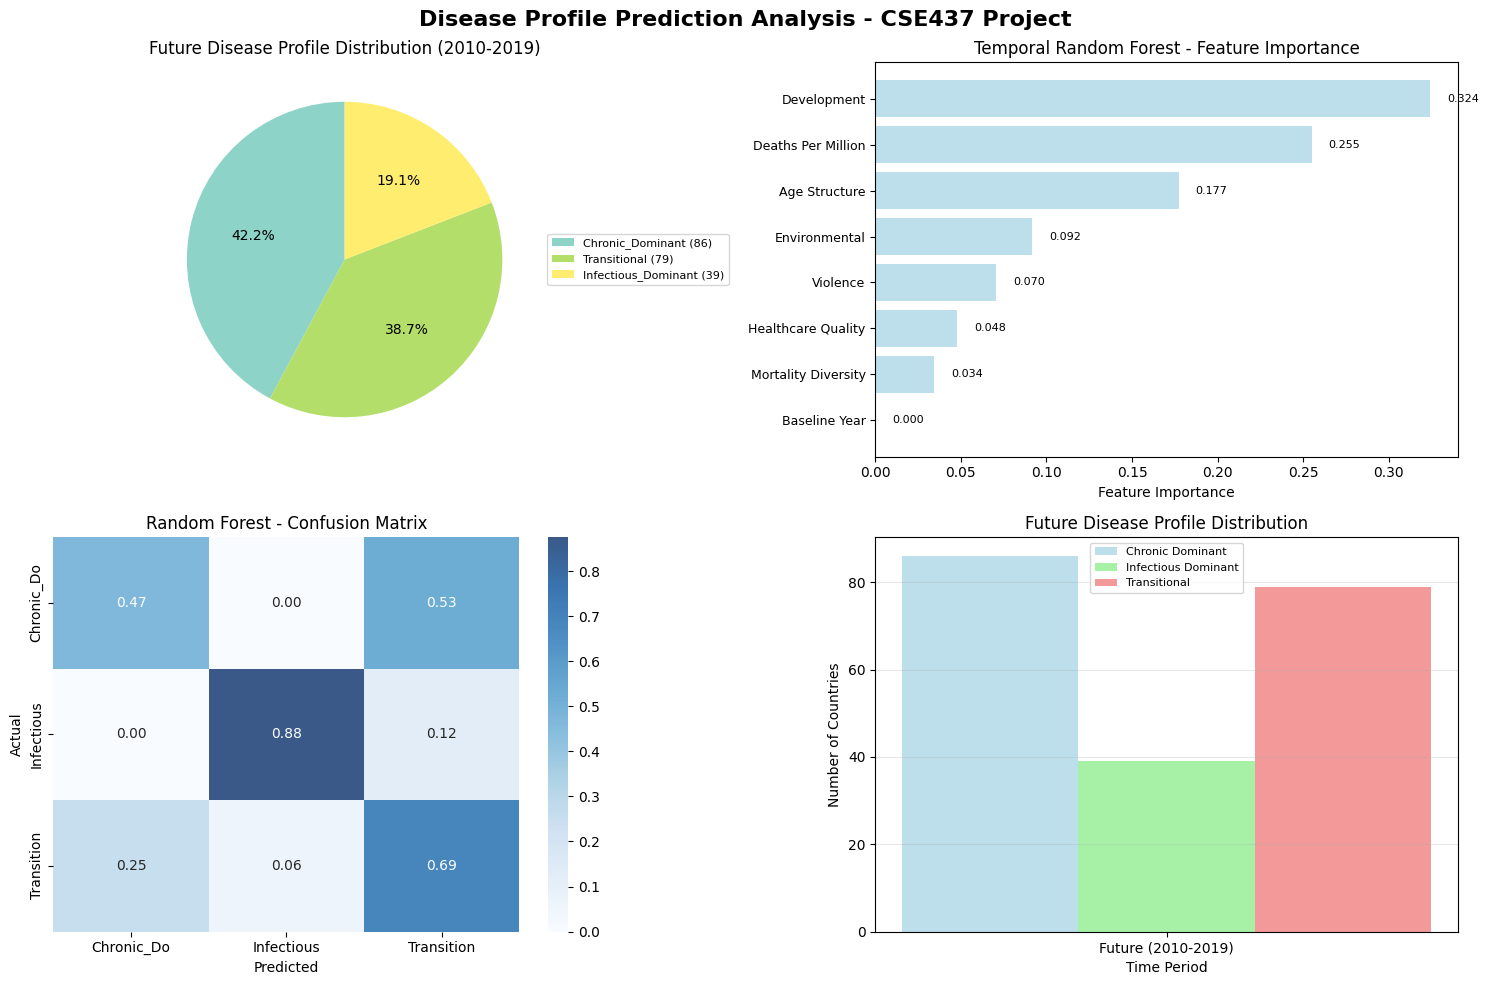

In [115]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Disease Profile Prediction Analysis - CSE437 Project', fontsize=16, fontweight='bold')
    future_profile_counts = temporal_df['Future_Disease_Profile'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(future_profile_counts)))
    
    wedges, texts, autotexts = axes[0,0].pie(future_profile_counts.values, labels=None, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0,0].set_title('Future Disease Profile Distribution (2010-2019)')
    
    legend_labels = [f"{profile.replace('_Future', '')} ({count})" for profile, count in future_profile_counts.items()]
    axes[0,0].legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8)
    
    top_rf_features = rf_importance_df.head(len(temporal_features))
    y_pos = range(len(top_rf_features))
    
    bars = axes[0,1].barh(y_pos, top_rf_features['Importance'], color='lightblue', alpha=0.8)
    axes[0,1].set_yticks(y_pos)
    rf_labels = [name.replace('Historical_', '').replace('_Proxy', '').replace('_', ' ') for name in top_rf_features['Feature']]
    axes[0,1].set_yticklabels(rf_labels, fontsize=9)
    axes[0,1].set_xlabel('Feature Importance')
    axes[0,1].set_title('Temporal Random Forest - Feature Importance')
    axes[0,1].invert_yaxis()
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        axes[0,1].text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', ha='left', va='center', fontsize=8)
    
    rf_cm_normalized = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
    sns.heatmap(rf_cm_normalized, annot=True, fmt='.2f', cmap='Blues', alpha=0.8,xticklabels=[cls[:10] for cls in classes], yticklabels=[cls[:10] for cls in classes], ax=axes[1,0])
    axes[1,0].set_title('Random Forest - Confusion Matrix')
    axes[1,0].set_xlabel('Predicted')
    axes[1,0].set_ylabel('Actual')

    transition_data = {
        'Chronic Dominant': [len(temporal_df[temporal_df['Future_Disease_Profile'] == 'Chronic_Dominant_Future'])],
        'Infectious Dominant': [len(temporal_df[temporal_df['Future_Disease_Profile'] == 'Infectious_Dominant_Future'])],
        'Transitional': [len(temporal_df[temporal_df['Future_Disease_Profile'] == 'Transitional_Future'])]
    }
    
    periods = ['Future (2010-2019)']
    x = np.arange(len(periods))
    width = 0.25
    
    chronic_counts = [transition_data['Chronic Dominant'][0]]
    infectious_counts = [transition_data['Infectious Dominant'][0]]
    transitional_counts = [transition_data['Transitional'][0]]
    
    axes[1,1].bar(x - width, chronic_counts, width, label='Chronic Dominant', alpha=0.8, color='lightblue')
    axes[1,1].bar(x, infectious_counts, width, label='Infectious Dominant', alpha=0.8, color='lightgreen')
    axes[1,1].bar(x + width, transitional_counts, width, label='Transitional', alpha=0.8, color='lightcoral')
    axes[1,1].set_title('Future Disease Profile Distribution')
    axes[1,1].set_xlabel('Time Period')
    axes[1,1].set_ylabel('Number of Countries')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(periods)
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('disease_profile_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    